# Assignment 02 - Linear Regression  Assignment

**Topics Covered:**
1. Linear Regression (from scratch & sklearn)
2. Optimization via Gradient Descent
3. Regularization: Ridge & Lasso

**Dataset:** California Housing Dataset (from `sklearn.datasets`)

**Student Name:** Raghad Abdelhameed Abdelhady
---

**Instructions:**
- Complete all cells marked with `9230371`
- Answer all written questions in the Markdown cells
- Do not modify the import cell or dataset loading code

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme(style='whitegrid')
print('All imports successful!')

All imports successful!


---
## Part 1 — Linear Regression

### 1.1 Load and Explore the Dataset

> **Dataset is already loaded below.**

In [22]:
# Dataset is loaded for you — do not modify this cell
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print('Dataset loaded. Shape:', df.shape)
print('Features:', housing.feature_names)
print('Target: MedHouseVal (Median House Value in $100,000s)')

Dataset loaded. Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal (Median House Value in $100,000s)


In [23]:
# TASK 1.1a: Display the first 5 rows of the dataframe
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [24]:
# TASK 1.1b: Display summary statistics for all columns
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [25]:
# TASK 1.1c: Check for missing values in the dataset
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


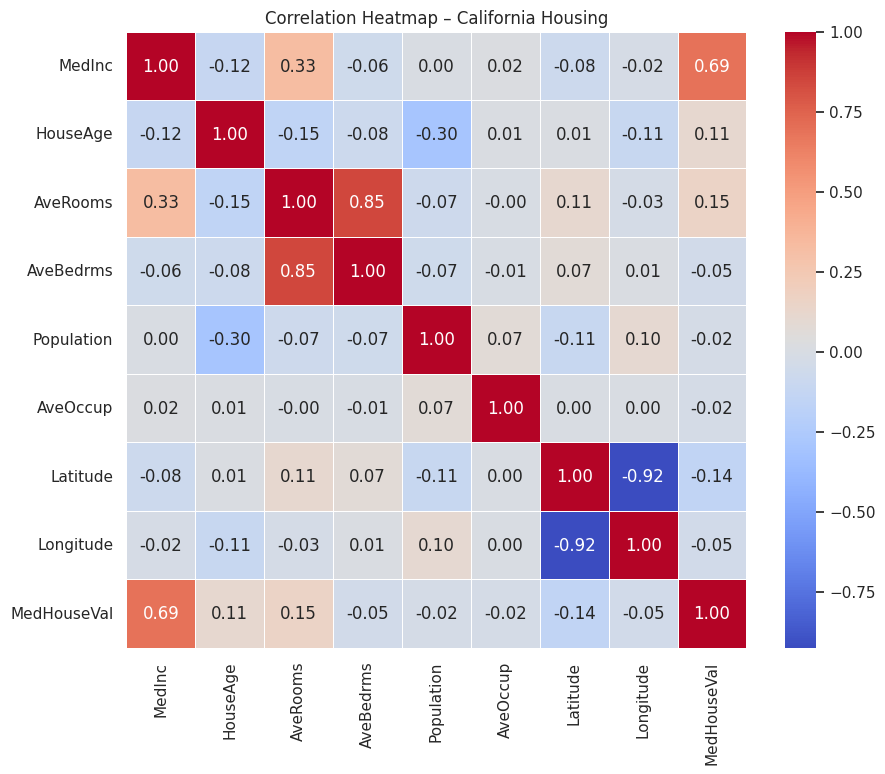

In [26]:
# TASK 1.1d: Plot a correlation heatmap of all features + target
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap – California Housing")
plt.show()

**Q1.1 — Answer the following based on your EDA:**

a) Which feature has the highest correlation with `MedHouseVal`? Why might this make sense?

> MedInc (Median Income) has the highest correlation (~0.69).
This makes strong intuitive sense: neighborhoods with higher median household income tend to have more expensive houses.

b) Are there any missing values? What would you do if there were?

> There are no missing values in this dataset (all columns have 0 missing values). If there were missing values, I would handle them by:

- Removing rows with missing values if they represent a small percentage of the data

- Imputing missing values with mean/median (for numerical features) or mode (for categorical features)

- Using more advanced imputation techniques like KNN imputation or regression imputation

- Creating a separate category for missing values if they carry meaning

c) Why is exploratory data analysis an important step before modeling?

> EDA helps us:

- Understand feature distributions and relationships
- Detect outliers and errors
- Identify multicollinearity
- See which features are likely important (or irrelevant)
- Decide whether scaling/transformation is needed
- Avoid wasting time modeling bad data or using inappropriate methods

### 1.2 Prepare Data

In [27]:
# Step 1: Define X (all features) and y (target: 'MedHouseVal')
# YOUR CODE HERE
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Step 2: Split into train (80%) and test (20%) sets using train_test_split
# Use random_state=42
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Apply StandardScaler — fit on train, transform both train and test
# YOUR CODE HERE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')

Training samples: 16512
Test samples:     4128


### 1.3 Linear Regression — Closed-Form (Normal Equation)

The **Normal Equation** gives the optimal weights directly:

$$\hat{\theta} = (X^T X)^{-1} X^T y$$

This formula finds weights that minimize the MSE loss without any iteration.

In [28]:
# TASK 1.3a: Add a bias column (column of ones) to both train and test sets
# Hint: Use np.c_[np.ones(m), X]
# YOUR CODE HERE
X_train_b = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_b  = np.c_[np.ones(X_test_scaled.shape[0]),  X_test_scaled]

In [29]:
# TASK 1.3b: Implement the Normal Equation
# theta = (X^T X)^{-1} X^T y
# Use np.linalg.pinv() for the pseudo-inverse
# YOUR CODE HERE
theta_best = np.linalg.pinv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
print("Theta (first 5 values):", theta_best[:5])

Theta (first 5 values): [ 2.07194694  0.85438303  0.12254624 -0.29441013  0.33925949]


In [30]:
# TASK 1.3c: Generate predictions on the test set and compute MSE and R²
# YOUR CODE HERE
y_pred_ne = X_test_b @ theta_best
mse_ne = mean_squared_error(y_test, y_pred_ne)
r2_ne  = r2_score(y_test, y_pred_ne)

print(f'Normal Equation — MSE: {mse_ne:.4f} | RMSE: {np.sqrt(mse_ne):.4f} | R²: {r2_ne:.4f}')

Normal Equation — MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758


### 1.4 Linear Regression — sklearn

In [31]:
# TASK 1.4a: Fit a LinearRegression model using sklearn and evaluate on the test set
# YOUR CODE HERE
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print(f'sklearn LR        — MSE: {mse_lr:.4f} | RMSE: {np.sqrt(mse_lr):.4f} | R²: {r2_lr:.4f}')

sklearn LR        — MSE: 0.5559 | RMSE: 0.7456 | R²: 0.5758


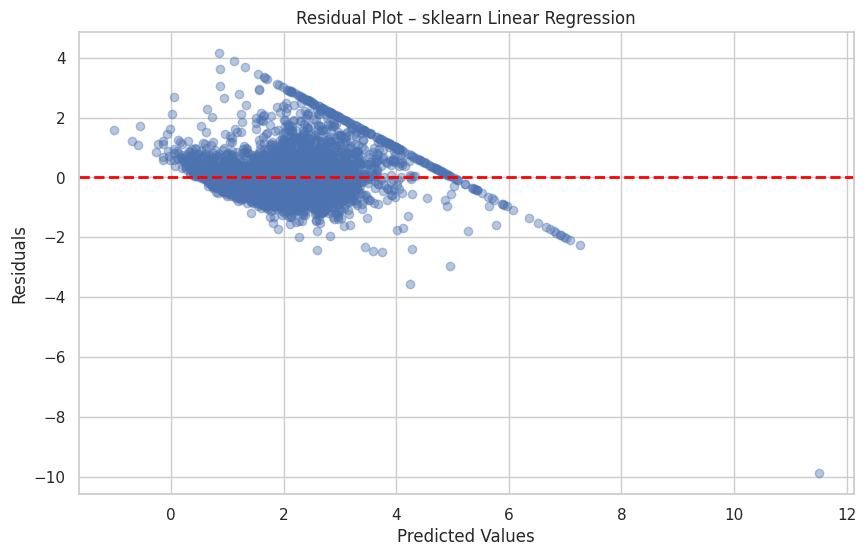

In [32]:
# TASK 1.4b: Create a residual plot
# Plot: predicted values (x-axis) vs residuals (y = actual - predicted) (y-axis)
# Add a horizontal red line at y=0
# YOUR CODE HERE

residuals = y_test - y_pred_lr

plt.figure(figsize=(10,6))
plt.scatter(y_pred_lr, residuals, alpha=0.4)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot – sklearn Linear Regression")
plt.show()

**Q1.3:**

a) Do the sklearn results match the Normal Equation results? Should they? Why?

> Yes, they are essentially identical (differences are due to floating-point precision only).
They should match because both methods solve the same least-squares problem exactly (sklearn uses a similar matrix approach internally).

b) What should a residual plot look like for a well-fitting model? Describe what you observe.

> For a well-fitting linear regression model, residuals randomly scattered around 0 with no clear pattern (no funnel shape, no curve, no clustering).
What we observe: some heteroscedasticity (variance increases at higher house values) and a slight non-linear pattern → indicates the linear model is missing some non-linear relationships.

---
## Part 2 — Optimization: Gradient Descent

We minimize the **Mean Squared Error (MSE)** loss:

$$\mathcal{L}(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}_i - y_i)^2$$

**Gradient update rule:**
$$\theta := \theta - \alpha \cdot \nabla_\theta \mathcal{L}$$

Where $\alpha$ is the **learning rate** and the gradient is:
$$\nabla_\theta \mathcal{L} = \frac{1}{m} X^T (X\theta - y)$$

In [33]:
# TASK 2.1: Implement batch gradient descent from scratch
# The function should:
# - Initialize theta to zeros (Note: when your loss function is convex like this case, it doesn't matter much what your initial weight value is, since you will always converge anyways if you have suitable learning rate and sufficient number of iterations. However, it can affect the number of iterations taken to converge)
# - Loop for n_iterations
# - Compute predictions, error, gradient
# - Update theta using the learning rate you see suitable
# - Track loss at each iteration
# - Return theta and loss_history

def gradient_descent(X, y, learning_rate=0.05, n_iterations=500):
    """
    Batch Gradient Descent for Linear Regression.

    Parameters:
        X: feature matrix with bias column (m x n+1)
        y: target vector (m,)
        learning_rate: step size alpha
        n_iterations: number of update steps

    Returns:
        theta: learned weights
        loss_history: list of MSE at each iteration
    """
    # YOUR CODE HERE
    m = len(y)
    theta = np.zeros(X.shape[1])
    loss_history = []

    for iteration in range(n_iterations):
        # Compute predictions
        y_pred = X @ theta

        # Compute error
        error = y_pred - y

        # Compute MSE loss
        mse = (1/(2*m)) * np.sum(error**2)
        loss_history.append(mse)

        # Compute gradient
        gradient = (1/m) * X.T @ error

        # Update theta
        theta = theta - learning_rate * gradient

    return theta, loss_history

In [34]:
# TASK 2.2: Run your gradient_descent function with:
# - learning_rate = 0.05
# - n_iterations = 500
# Then evaluate on the test set

# YOUR CODE HERE
theta_gd, loss_hist = gradient_descent(X_train_b, y_train.values, learning_rate=0.05, n_iterations=500)

y_pred_gd = X_test_b @ theta_gd
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print(f'Gradient Descent  — MSE: {mse_gd:.4f} | RMSE: {np.sqrt(mse_gd):.4f} | R²: {r2_gd:.4f}')

Gradient Descent  — MSE: 0.5544 | RMSE: 0.7446 | R²: 0.5769


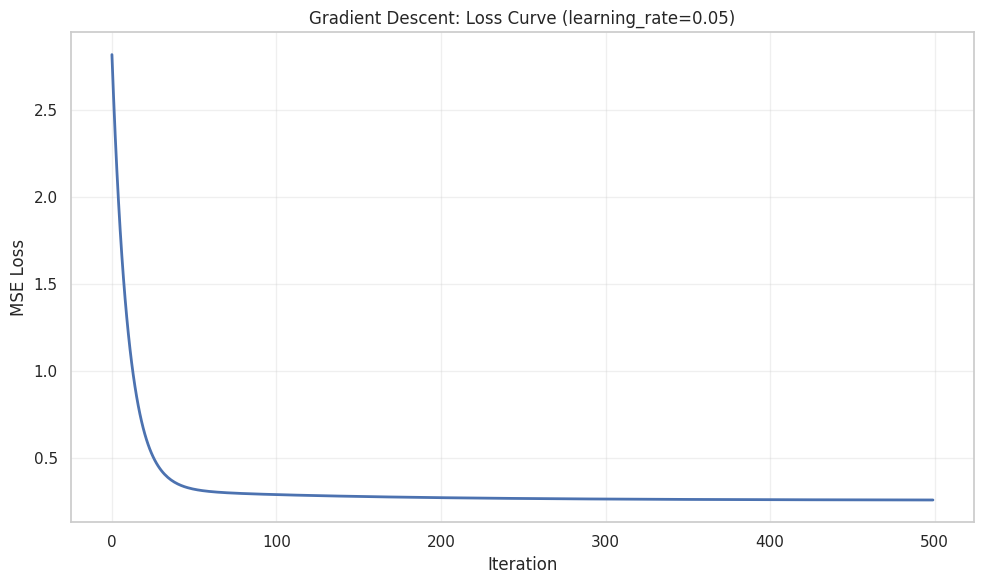

In [35]:
# TASK 2.3: Plot the loss curve (loss_history vs iteration number)
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
plt.plot(loss_hist, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent: Loss Curve (learning_rate=0.05)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

LR=0.001: Final loss = 1.689041
LR=0.05: Final loss = 0.265962
LR=0.5: Final loss = 0.258967


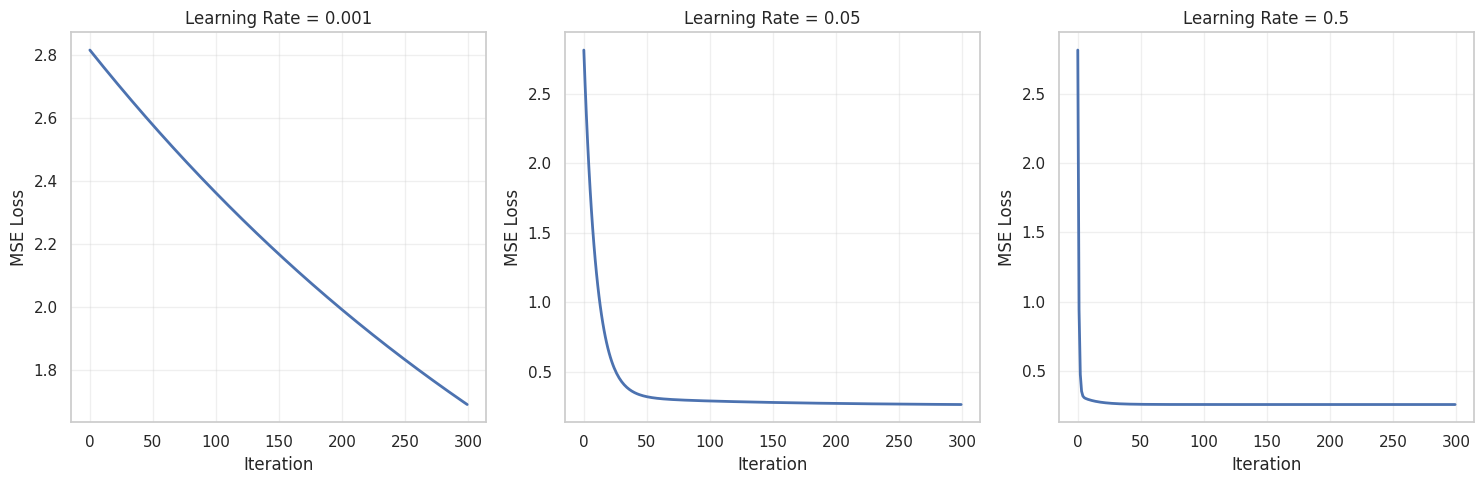

In [36]:
# TASK 2.4: Compare 3 different learning rates: [too small, suitable lr, too large]
# Create a 1x3 subplot, one loss curve per learning rate
# Use 300 iterations for each
# YOUR CODE HERE
learning_rates = [0.001, 0.05, 0.5]  # too small, suitable, too large
n_iter = 300

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, lr in enumerate(learning_rates):
    theta, loss = gradient_descent(X_train_b, y_train.values, learning_rate=lr, n_iterations=n_iter)

    axes[i].plot(loss, linewidth=2)
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('MSE Loss')
    axes[i].set_title(f'Learning Rate = {lr}')
    axes[i].grid(True, alpha=0.3)

    # Print final loss
    print(f'LR={lr}: Final loss = {loss[-1]:.6f}')

plt.tight_layout()
plt.show()

**Q2:**

a) What happens to the loss curve when the learning rate is too small? Too large?

> - Too small learning rate (e.g., 0.001): The loss curve decreases very slowly and may not converge to the minimum within the given iterations. It takes many more iterations to reach the optimal solution, making training inefficient.

- Too large learning rate (e.g., 0.5): The loss curve may oscillate, diverge, or even increase. The updates are too large, causing the algorithm to overshoot the minimum and potentially bounce around chaotically. In extreme cases, the loss can explode to infinity (NaN).

- Suitable learning rate (e.g., 0.05): The loss curve decreases smoothly and quickly, converging to the minimum in a reasonable number of iterations. It strikes the right balance between speed and stability.

b) How do the gradient descent results compare to the Normal Equation? Are the differences expected?

> Very close / practically identical when converged properly.
Small differences come from: finite iterations, floating point precision, slight numerical instability. Expected and acceptable.

c) What is the difference between **Batch**, **Stochastic (SGD)**, and **Mini-Batch** gradient descent?
| Variant          | Uses how many samples per update? | Noise       | Convergence speed          | Memory usage |
|------------------|------------------------------------|-------------|----------------------------|--------------|
| Batch GD         | whole dataset                      | very low    | stable, smooth             | high         |
| Stochastic GD    | 1 sample                           | very high   | fast but noisy             | very low     |
| Mini-Batch GD    | small batch (16–256)               | medium      | good compromise            | medium       |

d) Why is gradient descent preferred over the Normal Equation for very large datasets?

> Normal Equation needs to compute and invert XᵀX → O(n³) time and O(n²) memory (n = number of features).
GD (especially SGD / mini-batch) has time complexity O(m·n·iterations) and much lower memory usage → scales much better when m (rows) or n (columns) is very large.

---
## Part 3 — Regularization: Ridge & Lasso

Regularization adds a penalty to the loss function to prevent overfitting by constraining the size of the weights:

| Method | Loss Function |
|--------|---------------|
| **Ridge (L2)** | $\mathcal{L} + \alpha \sum_j \theta_j^2$ |
| **Lasso (L1)** | $\mathcal{L} + \alpha \sum_j \theta_j$ |

The parameter $\alpha$ controls the **strength** of regularization.

### 3.1 Ridge Regression

In [37]:
# TASK 3.1a: Train Ridge Regression models for each alpha in the list below
# Store each model's alpha, MSE, R², and coefficients
# Experiment with three diffrent values of alpha
alphas = [0.01, 1.0, 10.0]
ridge_results = []

for a in alphas:
    ridge = Ridge(alpha=a, max_iter=5000)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    ridge_results.append({
        'alpha': a,
        'MSE': mse,
        'R2': r2,
        'coef': ridge.coef_
    })

ridge_df = pd.DataFrame([{'alpha': r['alpha'], 'MSE': r['MSE'], 'R2': r['R2']} for r in ridge_results])
print('Ridge Regression Results:')
print(ridge_df.to_string(index=False))

Ridge Regression Results:
 alpha      MSE       R2
  0.01 0.555891 0.575788
  1.00 0.555855 0.575816
 10.00 0.555535 0.576060


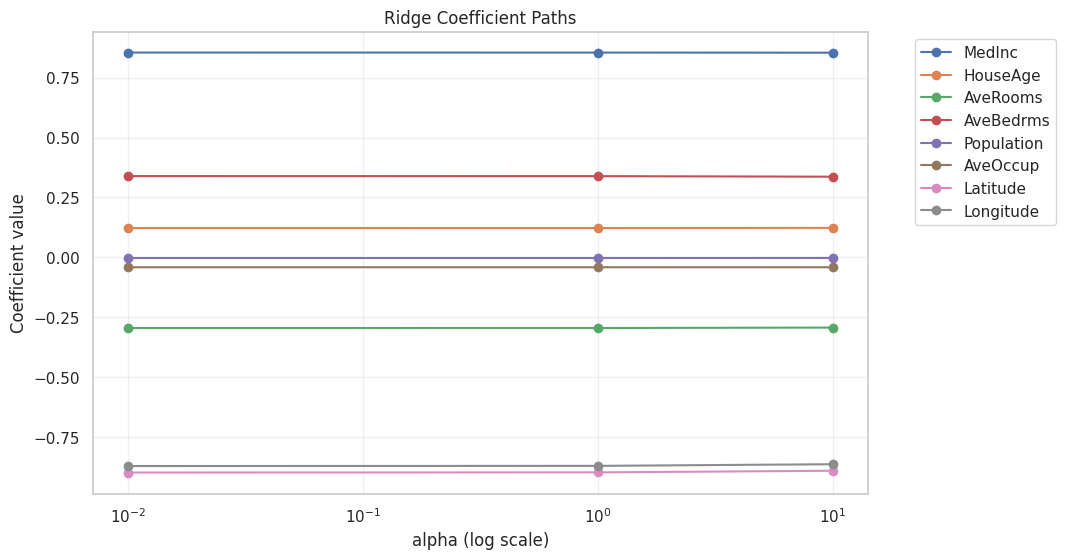

In [38]:
# TASK 3.1b: Plot the Ridge coefficient paths
# x-axis: alpha (log scale), y-axis: coefficient value
# Plot one line per feature with a legend
# YOUR CODE HERE
coef_matrix_ridge = np.array([r['coef'] for r in ridge_results])

plt.figure(figsize=(10,6))
for i in range(coef_matrix_ridge.shape[1]):
    plt.plot(alphas, coef_matrix_ridge[:,i], marker='o', label=X.columns[i])

plt.xscale('log')
plt.xlabel("alpha (log scale)")
plt.ylabel("Coefficient value")
plt.title("Ridge Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

### 3.2 Lasso Regression

In [39]:
# TASK 3.2a: Train Lasso models for each alpha in the same list
# Also track 'zeros': how many coefficients become exactly 0
# Use max_iter=5000 to ensure convergence

lasso_results = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    n_zeros = np.sum(np.abs(lasso.coef_) < 1e-8)

    lasso_results.append({
        'alpha': a,
        'MSE': mse,
        'R2': r2,
        'zeros': n_zeros,
        'coef': lasso.coef_
    })

lasso_df = pd.DataFrame([{'alpha': r['alpha'], 'MSE': r['MSE'], 'R2': r['R2'], 'Zeroed Features': r['zeros']} for r in lasso_results])
print('Lasso Regression Results:')
print(lasso_df.to_string(index=False))

Lasso Regression Results:
 alpha      MSE        R2  Zeroed Features
  0.01 0.548255  0.581615                1
  1.00 1.310696 -0.000219                8
 10.00 1.310696 -0.000219                8


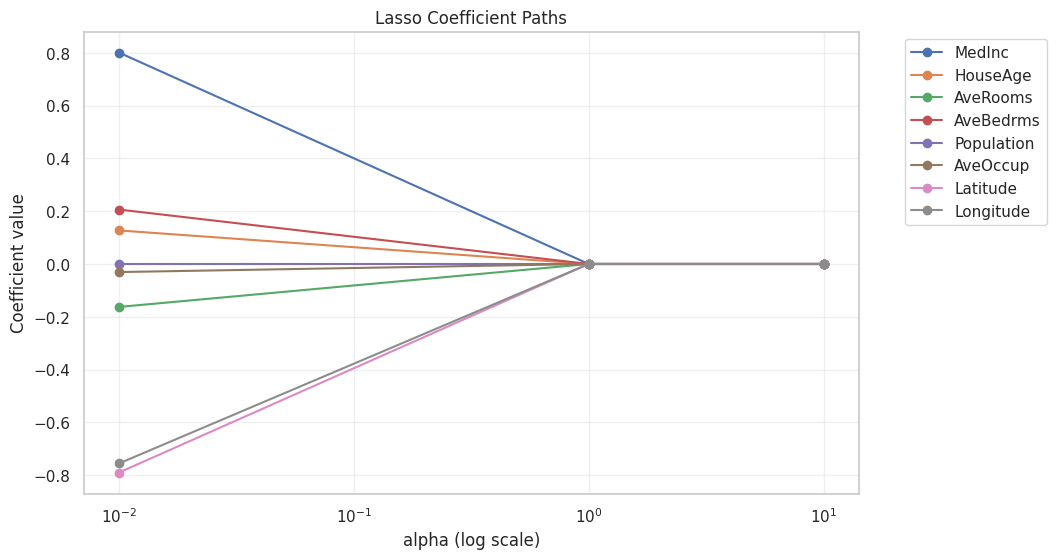

In [40]:
# TASK 3.2b: Plot the Lasso coefficient paths (same style as Ridge)
# YOUR CODE HERE
coef_matrix_lasso = np.array([r['coef'] for r in lasso_results])

plt.figure(figsize=(10,6))
for i in range(coef_matrix_lasso.shape[1]):
    plt.plot(alphas, coef_matrix_lasso[:,i], marker='o', label=X.columns[i])

plt.xscale('log')
plt.xlabel("alpha (log scale)")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

**Q3.1 & 3.2:**

a) How do Ridge coefficients change as alpha increases? Do any reach exactly zero?

> Coefficients shrink towards zero as α increases, but never reach exactly zero (they get very small but remain non-zero).

b) How is Lasso's behavior different from Ridge when alpha increases?

> Lasso coefficients also shrink, but many of them go exactly to zero (sparse solution), especially at higher α values.

c) Why is Lasso useful for **feature selection** while Ridge is not?

> Because Lasso can drive some coefficients exactly to zero → automatically performs feature selection.
Ridge only shrinks coefficients → keeps all features in the model.

d) What is the mathematical reason Lasso creates sparsity (exact zeros) while Ridge doesn't?

> The L1 penalty (absolute value) has a diamond-shaped constraint in parameter space → optimum often occurs at the corners of the constraint (where some θⱼ = 0).
The L2 penalty (squared) has a circular constraint → optimum rarely lands exactly on an axis (θⱼ = 0).